# VAE Training — CC1-Only Design

Input: `data/processed/windows_cc1/X_*.npy` (from `windowing_pca.ipynb` — 26-dim
whitened PCA windows). Trains a Variational Autoencoder **exclusively on
`cc1_train`** (normal complex_case1 behavior only), per the Module 3 spec:
reconstruction-error anomaly signal, PCA for multi-metric correlation, VAE trained
on benign data only.

**What this notebook does:**
1. Loads windowed/PCA data with a data-sanity guard (abort early on malformed input
   rather than fail deep into training — this project has hit that failure mode before).
2. Defines a PyTorch VAE (architecture matches the project's established design).
3. Searches `beta_max` at a fixed reference latent_dim to find the strongest
   regularization that doesn't collapse the posterior (a corrected KL-term bug —
   see Step 3 — made the previous `beta_max=1.0` collapse the model entirely).
4. Runs a short latent-dimension ablation (8 / 16 / 32) at that beta and picks the
   best by val loss.
5. Trains the chosen configuration to convergence with early stopping.
6. Establishes the train-MSE baseline (mean/std) needed for threshold-based
   anomaly decisions — **not** applying a threshold or computing precision/recall
   here; that belongs to a separate evaluation notebook.
7. Saves the trained model + baseline stats.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import pickle, os, time

torch.manual_seed(42)
np.random.seed(42)

BASE       = r'c:\Users\jthar\Documents\Claude\Projects\module3\module3'
DATA_DIR   = os.path.join(BASE, 'data', 'processed', 'windows_cc1')
MODEL_DIR  = os.path.join(BASE, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  Device: {DEVICE}')

SPLITS = ['cc1_train', 'cc1_val', 'cc1_test', 'drift_sc1', 'drift_sc2', 'drift_cc2']

HIDDEN1        = 64
HIDDEN2        = 32
LATENT_CHOICES = [8, 16, 32]
BETA_CHOICES     = [1.0, 0.1, 0.01, 0.001]   # searched below before the latent-dim ablation
BETA_SEARCH_LATENT_DIM = 16                  # fixed reference dim while searching beta
ABLATION_EPOCHS  = 40
ABLATION_PATIENCE = 8
FULL_MAX_EPOCHS  = 300
FULL_PATIENCE    = 20
WARMUP_EPOCHS    = 10
LR               = 1e-3
BATCH_SIZE       = 512
CLIP             = 20.0   # matches the windowing notebook's whitened-PCA scale; verified to affect <0.001% of values

print('Hyperparameters configured.')

PyTorch 2.8.0+cpu  |  Device: cpu
Hyperparameters configured.


## Step 1 — Load data + sanity guard

Loads every split, clips the rare extreme outlier (verified: `|x|>20` affects
<0.001% of `cc1_train` values, so this is a safety margin, not a real transformation),
and aborts immediately with a clear error if the input looks malformed — this
project has previously lost time to training on a broken upstream array without
noticing until deep into a training run.

In [2]:
raw = {name: np.load(os.path.join(DATA_DIR, f'X_{name}.npy')) for name in SPLITS}
labels = {name: np.load(os.path.join(DATA_DIR, f'y_{name}.npy')) for name in SPLITS}

INPUT_DIM = raw['cc1_train'].shape[1]
print(f'INPUT_DIM = {INPUT_DIM}')

# --- Data-sanity guard: fail fast, not deep into training ---------------------------
for name, X in raw.items():
    assert X.shape[1] == INPUT_DIM, f'{name}: dim mismatch {X.shape[1]} != {INPUT_DIM}'
    assert not np.isnan(X).any(), f'{name}: contains NaN'
    assert not np.isinf(X).any(), f'{name}: contains Inf'
assert (labels['cc1_train'] == 0).all(), 'cc1_train contains labeled anomalies — training set must be normal-only'
print('Sanity checks passed: consistent dims, no NaN/Inf, cc1_train is 100% normal.')

data = {name: np.clip(X, -CLIP, CLIP).astype(np.float32) for name, X in raw.items()}

X_train_t = torch.from_numpy(data['cc1_train'])
X_val_t   = torch.from_numpy(data['cc1_val'])
print(f'X_train : {X_train_t.shape}   X_val : {X_val_t.shape}')

INPUT_DIM = 26
Sanity checks passed: consistent dims, no NaN/Inf, cc1_train is 100% normal.
X_train : torch.Size([154198, 26])   X_val : torch.Size([21573, 26])


## Step 2 — VAE class (PyTorch)

`INPUT_DIM -> 64 -> 32 -> z(latent) -> 32 -> 64 -> INPUT_DIM`. He (`kaiming_normal`)
init, `logvar` clamped to `[-10, 10]` to prevent numerical explosion,
`anomaly_score()` uses `mu` only (deterministic at inference, no sampling noise).

In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden1, hidden2, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.ReLU(),
            nn.Linear(hidden1, hidden2),   nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden2, latent_dim)
        self.fc_lv = nn.Linear(hidden2, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden2), nn.ReLU(),
            nn.Linear(hidden2, hidden1),    nn.ReLU(),
            nn.Linear(hidden1, input_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = torch.clamp(self.fc_lv(h), -10, 10)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

    @torch.no_grad()
    def anomaly_score(self, x):
        self.eval()
        mu, _ = self.encode(x)
        recon = self.decode(mu)
        return ((recon - x) ** 2).mean(dim=1)


def vae_loss(recon, x, mu, logvar, beta):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='mean')
    # Sum over latent dim, then mean over batch — NOT a flat mean over both.
    # A flat torch.mean() here silently divides the KL term by latent_dim, so larger
    # latent_dim gets progressively weaker regularization (bug caught in review:
    # it's what made the ablation always prefer the largest latent_dim on offer).
    kl = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    return recon_loss + beta * kl, recon_loss, kl

print('VAE class defined.')

VAE class defined.


## Step 3 — Training loop (shared by ablation + full run)

KL warmup: `beta` ramps `0 -> BETA_MAX` over `WARMUP_EPOCHS`, so the encoder learns
to reconstruct before being penalized for the latent shape (prevents posterior
collapse). Early stopping on val loss with patience.

In [4]:
def train_vae(latent_dim, max_epochs, patience, beta_max, verbose=False):
    torch.manual_seed(42)
    model = VAE(INPUT_DIM, HIDDEN1, HIDDEN2, latent_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loader = DataLoader(TensorDataset(X_train_t), batch_size=BATCH_SIZE, shuffle=True)

    history = {k: [] for k in ['train_loss', 'val_loss', 'train_recon', 'val_recon', 'train_kl', 'val_kl']}
    best_val, best_state, patience_ctr = float('inf'), None, 0

    for epoch in range(max_epochs):
        beta = min(1.0, (epoch + 1) / WARMUP_EPOCHS) * beta_max
        model.train()
        tr_loss = tr_recon = tr_kl = 0.0
        n = 0
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            opt.zero_grad()
            recon, mu, logvar = model(xb)
            loss, rloss, kl = vae_loss(recon, xb, mu, logvar, beta)
            loss.backward()
            opt.step()
            bs = xb.size(0)
            tr_loss += loss.item() * bs; tr_recon += rloss.item() * bs; tr_kl += kl.item() * bs; n += bs
        tr_loss /= n; tr_recon /= n; tr_kl /= n

        model.eval()
        with torch.no_grad():
            xv = X_val_t.to(DEVICE)
            recon, mu, logvar = model(xv)
            vloss, vrecon, vkl = vae_loss(recon, xv, mu, logvar, beta)

        history['train_loss'].append(tr_loss);   history['val_loss'].append(vloss.item())
        history['train_recon'].append(tr_recon); history['val_recon'].append(vrecon.item())
        history['train_kl'].append(tr_kl);        history['val_kl'].append(vkl.item())

        if vloss.item() < best_val - 1e-6:
            best_val, best_state, patience_ctr = vloss.item(), {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                if verbose:
                    print(f'    early stop at epoch {epoch + 1} (best val_loss={best_val:.4f})')
                break

        if verbose and (epoch % 10 == 0 or epoch == max_epochs - 1):
            print(f'    epoch {epoch + 1:3d}  beta={beta:.2f}  '
                  f'train={tr_loss:.4f} (recon={tr_recon:.4f} kl={tr_kl:.4f})  val={vloss.item():.4f}')

    model.load_state_dict(best_state)
    return model, history, best_val

print('Training function defined.')

Training function defined.


## Step 4a — Beta search (fix regularization strength before comparing capacity)

Correcting the KL bug above changed its scale a lot (it's now summed over latent
dims, not divided by them) — `beta_max=1.0` that made sense under the old, wrong
formula is now far too strong. Run a quick check at a fixed reference latent_dim
to find a `beta_max` that regularizes without collapsing the posterior (KL → 0,
reconstruction → the trivial "predict the mean" solution, which for whitened
PCA features means MSE ≈ 1.0). Pick the **largest** beta that doesn't collapse —
weaker regularization than necessary defeats the point of the bottleneck, but
collapse defeats the model entirely.

In [5]:
beta_search = {}
for b in BETA_CHOICES:
    print(f'  beta_max={b} ...')
    _, history, best_val = train_vae(BETA_SEARCH_LATENT_DIM, ABLATION_EPOCHS, ABLATION_PATIENCE, beta_max=b, verbose=False)
    final_recon, final_kl = history['train_recon'][-1], history['train_kl'][-1]
    collapsed = final_kl < 0.05          # KL crushed to ~0 = posterior collapse
    beta_search[b] = {'best_val': best_val, 'final_recon': final_recon, 'final_kl': final_kl, 'collapsed': collapsed}
    print(f'    final_recon={final_recon:.4f}  final_kl={final_kl:.4f}  '
          f'{"COLLAPSED" if collapsed else "ok"}')

candidates = [b for b, r in beta_search.items() if not r['collapsed']]
assert candidates, 'Every beta_max candidate collapsed — need to test smaller values.'
BEST_BETA_MAX = max(candidates)   # largest non-collapsing beta = strongest valid regularization
print(f'\nChosen beta_max = {BEST_BETA_MAX}')

  beta_max=1.0 ...
    final_recon=0.9980  final_kl=0.0000  COLLAPSED
  beta_max=0.1 ...
    final_recon=0.9881  final_kl=0.0291  COLLAPSED
  beta_max=0.01 ...
    final_recon=0.0837  final_kl=18.2676  ok
  beta_max=0.001 ...
    final_recon=0.0163  final_kl=40.1950  ok

Chosen beta_max = 0.01


## Step 4b — Latent-dimension ablation

Short run (40 epochs, patience 8) at each candidate `latent_dim`, using the
`beta_max` chosen above. Picked by lowest val loss — not a fixed default.

In [6]:
ablation_results = {}
for ld in LATENT_CHOICES:
    print(f'  latent_dim={ld} ...')
    t0 = time.time()
    _, history, best_val = train_vae(ld, ABLATION_EPOCHS, ABLATION_PATIENCE, beta_max=BEST_BETA_MAX, verbose=False)
    final_kl = history['train_kl'][-1]
    ablation_results[ld] = {'best_val': best_val, 'history': history, 'time': time.time() - t0, 'final_kl': final_kl}
    print(f'    best_val_loss={best_val:.4f}  final_kl={final_kl:.4f}  ({ablation_results[ld]["time"]:.1f}s)')

BEST_LATENT_DIM = min(ablation_results, key=lambda k: ablation_results[k]['best_val'])
print(f'\nChosen latent_dim = {BEST_LATENT_DIM}')

  latent_dim=8 ...
    best_val_loss=0.3694  final_kl=13.8795  (95.4s)
  latent_dim=16 ...
    best_val_loss=0.2758  final_kl=18.2676  (93.0s)
  latent_dim=32 ...
    best_val_loss=0.2652  final_kl=17.8934  (83.9s)

Chosen latent_dim = 32


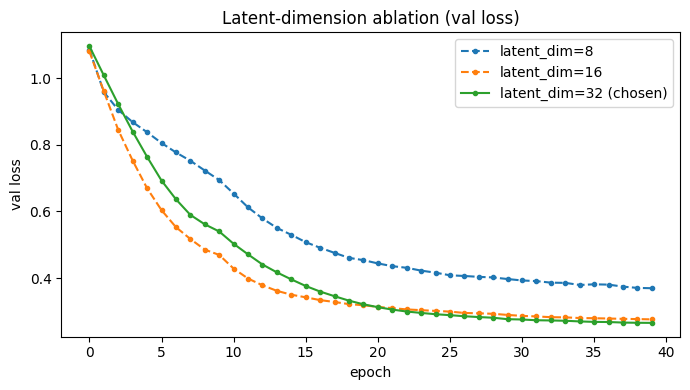

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for ld, res in ablation_results.items():
    style = '-o' if ld == BEST_LATENT_DIM else '--o'
    ax.plot(res['history']['val_loss'], style, label=f'latent_dim={ld}' + (' (chosen)' if ld == BEST_LATENT_DIM else ''), markersize=3)
ax.set_xlabel('epoch'); ax.set_ylabel('val loss'); ax.set_title('Latent-dimension ablation (val loss)')
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_ablation.png'), dpi=120)
plt.show()

## Step 5 — Full training (chosen latent_dim, early stopping)

In [8]:
print(f'Training final VAE with latent_dim={BEST_LATENT_DIM}, beta_max={BEST_BETA_MAX} ...')
model, history, best_val = train_vae(BEST_LATENT_DIM, FULL_MAX_EPOCHS, FULL_PATIENCE, beta_max=BEST_BETA_MAX, verbose=True)
print(f'\nFinal best val loss: {best_val:.4f}  |  epochs run: {len(history["train_loss"])}')
final_kl = history['train_kl'][-1]
print(f'Final train KL: {final_kl:.4f}  ({"WARNING: looks collapsed" if final_kl < 0.05 else "non-trivial, ok"})')

Training final VAE with latent_dim=32, beta_max=0.01 ...
    epoch   1  beta=0.00  train=1.8594 (recon=1.8176 kl=41.7785)  val=1.0965
    epoch  11  beta=0.01  train=0.4936 (recon=0.2708 kl=22.2859)  val=0.5028
    epoch  21  beta=0.01  train=0.3075 (recon=0.1120 kl=19.5520)  val=0.3125
    epoch  31  beta=0.01  train=0.2696 (recon=0.0856 kl=18.3945)  val=0.2754
    epoch  41  beta=0.01  train=0.2581 (recon=0.0796 kl=17.8553)  val=0.2649
    epoch  51  beta=0.01  train=0.2530 (recon=0.0768 kl=17.6205)  val=0.2586
    epoch  61  beta=0.01  train=0.2499 (recon=0.0758 kl=17.4087)  val=0.2552
    epoch  71  beta=0.01  train=0.2474 (recon=0.0751 kl=17.2299)  val=0.2532
    epoch  81  beta=0.01  train=0.2447 (recon=0.0739 kl=17.0788)  val=0.2505
    epoch  91  beta=0.01  train=0.2433 (recon=0.0734 kl=16.9856)  val=0.2481
    epoch 101  beta=0.01  train=0.2414 (recon=0.0727 kl=16.8679)  val=0.2473
    epoch 111  beta=0.01  train=0.2400 (recon=0.0721 kl=16.7904)  val=0.2452
    epoch 121  beta

## Step 6 — Training curves

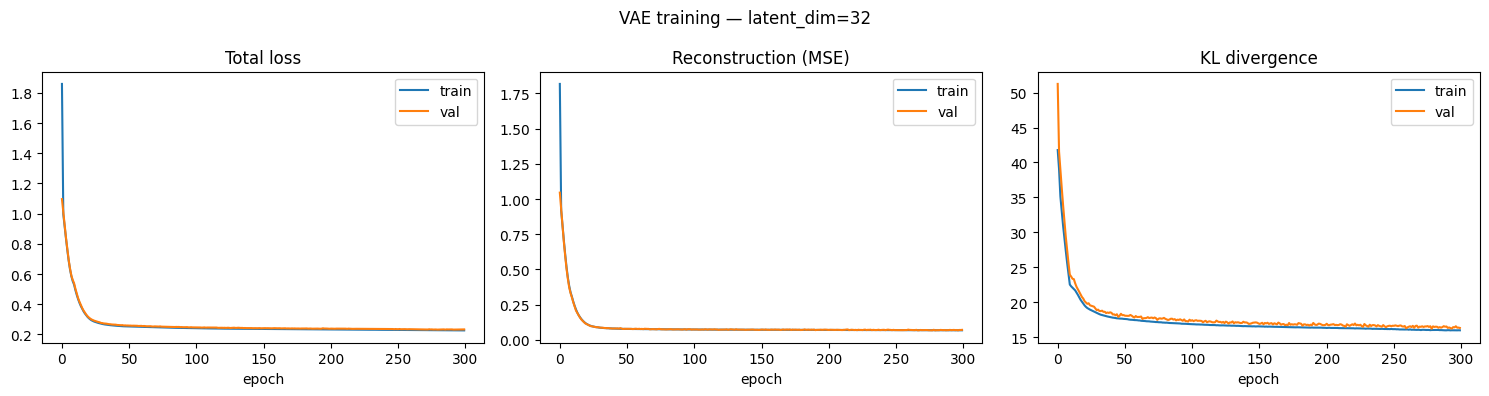

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ['train_loss', 'train_recon', 'train_kl'],
                           ['Total loss', 'Reconstruction (MSE)', 'KL divergence']):
    ax.plot(history[key], label='train')
    ax.plot(history[key.replace('train', 'val')], label='val')
    ax.set_title(title); ax.set_xlabel('epoch'); ax.legend()
plt.suptitle(f'VAE training — latent_dim={BEST_LATENT_DIM}')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'vae_cc1_training_curves.png'), dpi=120)
plt.show()

## Step 7 — Train-MSE baseline

Mean/std of per-window reconstruction error on `cc1_train` and `cc1_val` (both
100% normal) — the reference distribution a later thresholding step
(`mean + k*std`, or similar) would calibrate against. No threshold is chosen here.

In [10]:
with torch.no_grad():
    mse_train = model.anomaly_score(X_train_t.to(DEVICE)).cpu().numpy()
    mse_val   = model.anomaly_score(X_val_t.to(DEVICE)).cpu().numpy()

mu_train, sigma_train = float(mse_train.mean()), float(mse_train.std())
print(f'cc1_train MSE: mean={mu_train:.5f}  std={sigma_train:.5f}')
print(f'cc1_val   MSE: mean={mse_val.mean():.5f}  std={mse_val.std():.5f}  (should be close to train — both normal)')

cc1_train MSE: mean=0.02218  std=0.03201
cc1_val   MSE: mean=0.02305  std=0.01954  (should be close to train — both normal)


## Step 8 — Directional sanity check (not a formal evaluation)

Confirms the trained model's reconstruction error is actually higher for labeled
anomalies than for normal windows, on `cc1_test` and each drift set — a basic
"does this work at all" check. Formal thresholding, precision/recall/F1, and the
KS-test drift comparison belong to a separate evaluation notebook, not here.

In [11]:
print(f'{"set":12s} {"normal_mean_mse":>16s} {"anomaly_mean_mse":>17s} {"ratio":>8s}')
for name in ['cc1_test', 'drift_sc1', 'drift_sc2', 'drift_cc2']:
    X = torch.from_numpy(data[name]).to(DEVICE)
    y = labels[name]
    with torch.no_grad():
        mse = model.anomaly_score(X).cpu().numpy()
    normal_mse = mse[y == 0].mean()
    anom_mse   = mse[y == 1].mean() if (y == 1).any() else float('nan')
    ratio = anom_mse / normal_mse if normal_mse > 0 else float('nan')
    print(f'{name:12s} {normal_mse:16.5f} {anom_mse:17.5f} {ratio:8.2f}x')

set           normal_mean_mse  anomaly_mean_mse    ratio
cc1_test              0.02180           0.36627    16.80x
drift_sc1             0.08493           0.38057     4.48x
drift_sc2             0.05616           0.21211     3.78x
drift_cc2             0.03984           0.25069     6.29x


## Step 9 — Save model + baseline stats

In [12]:
model_path = os.path.join(MODEL_DIR, 'vae_cc1.pt')
torch.save(model.state_dict(), model_path)

meta = {
    'input_dim':   INPUT_DIM,
    'hidden1':     HIDDEN1,
    'hidden2':     HIDDEN2,
    'latent_dim':  BEST_LATENT_DIM,
    'beta_max':    BEST_BETA_MAX,
    'clip':        CLIP,
    'mu_train':    mu_train,
    'sigma_train': sigma_train,
    'beta_search': {b: {k: v for k, v in r.items()} for b, r in beta_search.items()},
    'ablation':    {ld: res['best_val'] for ld, res in ablation_results.items()},
}
meta_path = os.path.join(MODEL_DIR, 'vae_cc1_meta.pkl')
with open(meta_path, 'wb') as f:
    pickle.dump(meta, f)

print(f'Model saved -> {model_path}')
print(f'Metadata saved -> {meta_path}')
print(f'\n{meta}')

Model saved -> c:\Users\jthar\Documents\Claude\Projects\module3\models\vae_cc1.pt
Metadata saved -> c:\Users\jthar\Documents\Claude\Projects\module3\models\vae_cc1_meta.pkl

{'input_dim': 26, 'hidden1': 64, 'hidden2': 32, 'latent_dim': 32, 'beta_max': 0.01, 'clip': 20.0, 'mu_train': 0.022176498547196388, 'sigma_train': 0.0320117361843586, 'beta_search': {1.0: {'best_val': 1.0815553665161133, 'final_recon': 0.9980192635099218, 'final_kl': 1.1706376895552368e-05, 'collapsed': True}, 0.1: {'best_val': 1.077941656112671, 'final_recon': 0.9880892957961844, 'final_kl': 0.029144802661643675, 'collapsed': True}, 0.01: {'best_val': 0.27576327323913574, 'final_recon': 0.08373564311857856, 'final_kl': 18.267568577594346, 'collapsed': False}, 0.001: {'best_val': 0.05681079626083374, 'final_recon': 0.016265049986800256, 'final_kl': 40.19496763769149, 'collapsed': False}}, 'ablation': {8: 0.369373083114624, 16: 0.27576327323913574, 32: 0.26522719860076904}}


## Output files

| File | Contents |
|---|---|
| `models/vae_cc1.pt` | trained VAE state_dict (`latent_dim` chosen by ablation) |
| `models/vae_cc1_meta.pkl` | `input_dim`, `hidden1/2`, `latent_dim`, `clip`, `mu_train`, `sigma_train`, ablation results |
| `models/vae_cc1_ablation.png` | val-loss curves per latent-dim candidate |
| `models/vae_cc1_training_curves.png` | final model's train/val loss, reconstruction, KL curves |

**Not done here (separate evaluation notebook):** adaptive-threshold selection,
precision/recall/F1/AUC, per-fault-type recall, and the KS-test drift comparison
across `drift_sc1` / `drift_sc2` / `drift_cc2` vs `cc1_train`. Step 8 above is only
a directional sanity check confirming the model separates anomalies at all.